In [1]:
# import JupyterNotebooksLib as slicernb
# import DICOMLib.DICOMUtils as utils
# import DICOMScalarVolumePlugin
import pandas as pd
import numpy as np

# import DICOMScalarVolumePlugin
import os
import time

from pydicom import dcmread
import matplotlib.pyplot as plt
import pydicom
from matplotlib.colors import LinearSegmentedColormap



In [2]:
colors_1=["white", "darkmagenta","blue","green","yellow","orange","red", "black"]
nodes_1 = [0.0, 0.04, 0.078, 0.14, 0.17, 0.23, 0.34, 1.0]
Monteris_cmap = LinearSegmentedColormap.from_list("mycmap", list(zip(nodes_1, colors_1)))

In [15]:
def load_dicom_from_computer(file_path):
    
    # Clear scene
    slicer.mrmlScene.Clear(False)

    folder = file_path

    result = utils.importDicom(folder)
    print("Imported one file correctly:",result)
    scalarVolumeReader = DICOMScalarVolumePlugin.DICOMScalarVolumePluginClass()
    print("scalarVolumeReader", scalarVolumeReader)
    db = slicer.dicomDatabase
    print("db", db.patients())


    for patient in db.patients():
        for study in db.studiesForPatient(patient):
            for series in db.seriesForStudy(study):
                print('looking at series ' + series + ' for patient ' + patient)
                files = db.filesForSeries(series)
                loadable = scalarVolumeReader.examineForImport([files])[0]
                volume = scalarVolumeReader.load(loadable)
    return volume

# file_path = r"E:\MRgLITT Data\new data\2021-12-21\MTLE-2.2DTP\LP-0002\LP-0002-01-01-02\anatomicalData"
# file_path = r"E:\MRgLITT Data\new data\2021-12-21\MTLE-2.2DTP\LP-0001\LP-0001-01-01-01\temperatureData"
# file_path = r"E:\MRgLITT Data\new data\2021-12-21\MTLE-2.2DTP\LP-0001\LP-0001-01-01-01\anatomicalProbesEye"
file_path = r"E:\MRgLITT Data\new data\2021-12-21\MTLE-2.2DTP\LP-0005\LP-0005-01-01-04\anatomicalProbesEye"
volume = load_dicom_from_computer(file_path)

Imported one file correctly: True
scalarVolumeReader <DICOMScalarVolumePlugin.DICOMScalarVolumePluginClass object at 0x0000021A99C3CF28>
db ('67', '68')
looking at series 1.3.6.1.4.1.57582.637756755920721614.997400869.35615 for patient 67
Loading with imageIOName: GDCM
looking at series 1.3.6.1.4.1.57582.637756755920721614.536959543.35616 for patient 67
Loading with imageIOName: GDCM
looking at series 1.3.6.1.4.1.57582.637756752288561038.1201321969.19170 for patient 68
Loading with imageIOName: GDCM


Irregular volume geometry detected (maximum error of 0.00301025 mm is above tolerance threshold of 0.001 mm).  Regularization transform is not added, as the option is disabled.


looking at series 1.3.6.1.4.1.57582.637756752288561038.2004798982.19171 for patient 68
Loading with imageIOName: GDCM


Irregular volume geometry detected (maximum error of 0.00301102 mm is above tolerance threshold of 0.001 mm).  Regularization transform is not added, as the option is disabled.


In [3]:
def find_laser_location(filepath):
    
    # Takes the file's folder
    print("in function file path", filepath)
    # read the CSV file
    df = pd.read_csv(filepath)

    #print the first five rows
    #print(df.head(15))
    
    #Find the probe location from pandas dataframe 
    laser_loc_x = float(df.iloc[10][1])
    laser_loc_y = float(df.iloc[11][1])
    laser_loc_z = float(df.iloc[12][1])
    
    print("details:", laser_loc_x, laser_loc_y, laser_loc_z)
    return laser_loc_x, laser_loc_y, laser_loc_z

# other_file_path = r"E:\MRgLITT Data\new data\2021-12-21\MTLE-2.2DTP\LP-0001\LP-0001-01-01-01\caseNotes.csv"
other_file_path = r"E:\Documents\MTLE\LP-0001\LP-0001-01-01-01\caseNotes.csv"
laser_loc_x, laser_loc_y, laser_loc_z = find_laser_location(other_file_path)

in function file path E:\Documents\MTLE\LP-0001\LP-0001-01-01-01\caseNotes.csv
details: 14.80606195 15.85856865 27.5923181


In [26]:
dicom_file_path = "E:\Documents\MTLE\LP-0001\LP-0001-01-01-01\\anatomicalProbesEye\coarse.S2.dcm"
# dicom_file_path = "E:\\Documents\\MTLE\\LP-0001\\LP-0001-01-01-01\\anatomicalData\\089.dcm"
dicom_uncropped = pydicom.dcmread(dicom_file_path)

print(dicom_uncropped)

Dataset.file_meta -------------------------------
(0002, 0000) File Meta Information Group Length  UL: 198
(0002, 0001) File Meta Information Version       OB: b'\x00\x01'
(0002, 0002) Media Storage SOP Class UID         UI: MR Image Storage
(0002, 0003) Media Storage SOP Instance UID      UI: 2.16.840.1.114226.1288108068.1871140.221.249
(0002, 0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002, 0012) Implementation Class UID            UI: 2.16.840.1.114226
(0002, 0013) Implementation Version Name         SH: 'IDL_2.1.4_3.8.0'
(0002, 0016) Source Application Entity Title     AE: 'IDL_DICOMEX'
-------------------------------------------------
(0008, 0005) Specific Character Set              CS: 'ISO_IR 100'
(0008, 0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'P', 'ND']
(0008, 0016) SOP Class UID                       UI: MR Image Storage
(0008, 0018) SOP Instance UID                    UI: 1.3.6.1.4.1.57582.637756755920911510.21390823

In [160]:
from nibabel.affines import apply_affine

ds = pydicom.dcmread(dicom_file_path)
laser_point = np.array([14.80606195, 15.85856865, 27.5923181, 1])
Sxyz = ds[0x0020,0x0032].value
Xxyz = ds[0x0020,0x0037].value
Yxyz = ds[0x0020,0x0037].value

Xxyz = np.array(Xxyz[0:3])
Yxyz = np.array(Yxyz[3:6])

itri = ds[0x0028,0x0030].value
jtri = ds[0x0028,0x0030].value

print("point:", laser_point[0:3])
print("Sxyz:",Sxyz)
print("Xxyz:",Xxyz)
print("Yxyz:",Yxyz)
print("itri:",2)

# np.array([[Xxyz[0]*2, Yxyz[0]*2, 0, Sxyz[0]], [Xxyz[1]*2, Yxyz[1]*2, 0, Sxyz[1]], ])

transformation_mat = np.array([[Xxyz[0]*2, Yxyz[0]*2, 0, Sxyz[0]],
                                [Xxyz[1]*2, Yxyz[1]*2, 0, Sxyz[1]],
                                [Xxyz[2]*2, Yxyz[2]*2, 0, Sxyz[2]],
                                [0, 0, 0, 1]]  )


print(transformation_mat)

new_p = np.dot(transformation_mat,laser_point)

print(new_p)



point: [14.80606195 15.85856865 27.5923181 ]
Sxyz: [-130.25993347168, -24.56925201416, 125.514106750488]
Xxyz: [ 9.57271743e-01 -2.89189919e-01 -1.04475967e-09]
Yxyz: [ 0.1838211   0.60848032 -0.77198543]
itri: 2
[[ 1.91454349e+00  3.67642193e-01  0.00000000e+00 -1.30259933e+02]
 [-5.78379838e-01  1.21696064e+00  0.00000000e+00 -2.45692520e+01]
 [-2.08951935e-09 -1.54397086e+00  0.00000000e+00  1.25514107e+02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
[-96.08280504 -13.83352586 101.02893884   1.        ]


array([-96.08280504, -13.83352586, 101.02893884])

In [156]:
from PIL import Image

# Load the two PNG images
image1 = Image.open("temp.png")
image2 = Image.open("testlaser.png")

# Make sure images got an alpha channel
image5 = image1.convert("RGBA")
image6 = image2.convert("RGBA")

# alpha-blend the images with varying values of alpha
alphaBlended1 = Image.blend(image5, image6, alpha=.2)
alphaBlended2 = Image.blend(image5, image6, alpha=.4)

# Display the alpha-blended images
alphaBlended1.show()
alphaBlended2.show()

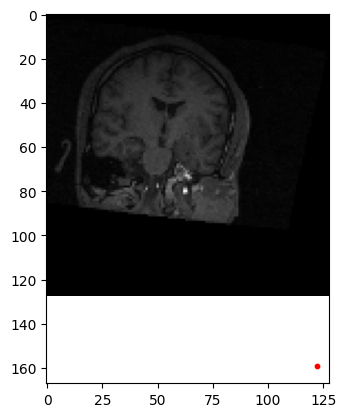

In [164]:
import matplotlib.pyplot as plt
import pydicom
import pydicom.data
import nibabel as nib

# # Load the DICOM file
ds = pydicom.dcmread("E:\Documents\MTLE\LP-0001\LP-0001-01-01-01\\anatomicalProbesEye\coarse.S2.dcm")
# ds = pydicom.dcmread("E:\Documents\MTLE\LP-0001\LP-0001-01-01-01\\anatomicalData\\089.dcm")

# Plot the DICOM image
plt.imshow(ds.pixel_array, cmap='gray')

# nifti = "E:\Documents\\1_fl3d_ax_sel_10x10x10.nii.gz"
# image_raw = nib.load(nifti)
# array = image_raw.get_fdata()
# rotated_array = np.transpose(array, (2, 0, 1))
# rotated_array  = np.flipud(rotated_array)

# plt.imshow(rotated_array[:,:,127], cmap = 'gray')
 
 #([[[ 122.27494696, -131.76260997,   43.80766615]]])

# Coordinates of the point you want to plot (replace these with actual coordinates)
x =  122.27494699
# x = 154
y =  159.01378366
# z = -1* new_p[2]

# Plot the point as a red dot
plt.scatter(x, y, color='red', s=10)
# plt.scatter(14.80606195, 15.85856865, color='blue', s=30)

# Show the plot
plt.show()

In [161]:
from nibabel.affines import apply_affine
import numpy.linalg as npl

nifti = "E:\Documents\\1_fl3d_ax_sel_10x10x10.nii.gz"
img = nib.load(nifti)

print(img.affine)

M = img.affine[:3, :3]
abc = img.affine[:3, 3]

def f(i, j, k):
   """ Return X, Y, Z coordinates for i, j, k """
   return M.dot([i, j, k]) + abc

epi_vox_center = (np.array(img.shape) - 1) / 2.
# f(laser_point[0], laser_point[1], laser_point[2])

laser = [laser_point[0:3]]
point = np.array([laser])
img.affine.dot(list(epi_vox_center) + [1])


trans = npl.inv(img.affine)

projected_point = apply_affine(trans, point)
projected_point





[[-1.00000000e+00  2.05103004e-10  0.00000000e+00  1.37081009e+02]
 [ 1.90568006e-10  9.29132581e-01  3.69746774e-01 -1.56699493e+02]
 [-7.58359972e-11 -3.69746774e-01  9.29132581e-01  2.40343990e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


array([[[122.27494699, 159.01378366,  67.10856337]]])

In [115]:
def project_point(second_slice_path):
    #read the second slice
    #second_slice_path = r"E:\MRgLITT Data\new data\2021-12-21\MTLE-2.2DTP\LP-0001\LP-0001-01-01-01\anatomicalProbesEye\coarse.S2.dcm"
    ds = dcmread(second_slice_path)
    #print(ds)
    #print(ds.file_meta)

    #extract image position
    Image_Position_1 = ds[0x0020,0x0032].value
    lst_image_position=[]
    lst_image_position.append(float(Image_Position_1[0]))
    lst_image_position.append(float(Image_Position_1[1]))
    lst_image_position.append(float(Image_Position_1[2]))
#     lst_image_position = list(Image_Position_1 )
    print("lst_image_position", lst_image_position)

    #extract image orientation
    Image_orientation_1 = ds[0x0020,0x0037].value
    lst_image_orientation = list(Image_orientation_1)
    #make it as two vectors for rows and columns
    row_vector = np.array(lst_image_orientation[0:3])
#     row_vector = lst_image_orientation[3:6]
    print("row_vector:", row_vector)
    column_vector = np.array(lst_image_orientation[3:6])
#     column_vector = lst_image_orientation[0:3]
    print("column_vector: ", column_vector)

    #normal plane computed as the cross-product of the row and column vectors
    normal_plane = np.cross(row_vector,column_vector)

    print("normal_plane: ", normal_plane)
    
    #project laser location
    point=[]
    point.append(laser_loc_x)
    point.append(laser_loc_y)
    point.append(laser_loc_z)
    print("original laser location: ", point)
    print(type(point[0]))

    print("lst_image_position:", lst_image_position)
    print(type(lst_image_position[0]))
    #orig = p (Image position)
    # 1) Make a vector from your orig point to the point of interest:
    # v = point-orig (in each dimension);
    v = list(np.array(point) - np.array(lst_image_position))
#     v = point - lst_image_position
    print("point",point)

    # 2) Take the dot product of that vector with the unit normal vector n:
    # dist = vx*nx + vy*ny + vz*nz; dist = scalar distance from point to plane along the normal
    dist = np.dot(v , normal_plane)
    print("dist:", dist)

    # 3) Multiply the unit normal vector by the distance, and subtract that vector from your point.
    # projected_point = point - dist*normal;
    #point is the imported laser location from CSV
    projected_point = point - dist*normal_plane;
    print("projected_point: ", projected_point)
    
    return normal_plane, point, projected_point, lst_image_position

second_slice_path = r"E:\Documents\MTLE\LP-0001\LP-0001-01-01-01\\anatomicalProbesEye\coarse.S2.dcm"
normal_plane, point ,projected_point, lst_image_position = project_point(second_slice_path)

lst_image_position [-130.25993347168, -24.56925201416, 125.514106750488]
row_vector: [ 9.57271743e-01 -2.89189919e-01 -1.04475967e-09]
column_vector:  [ 0.1838211   0.60848032 -0.77198543]
normal_plane:  [0.2232504  0.73899984 0.63564022]
original laser location:  [14.80606195, 15.85856865, 27.5923181]
<class 'float'>
lst_image_position: [-130.25993347168, -24.56925201416, 125.514106750488]
<class 'float'>
point [14.80606195, 15.85856865, 27.5923181]
dist: 0.01916735056871488
projected_point:  [14.80178283 15.84440398 27.58013456]


Image Position (0020,0032) specifies the x, y, and z coordinates of the upper left hand corner of the image; it is the center of the first voxel transmitted. Image Orientation (0020,0037) specifies the direction cosines of the first row and the first column with respect to the patient. These Attributes shall be provide as a pair. Row value for the x, y, and z axes respectively followed by the Column value for the x, y, and z axes respectively.

In [5]:
def create_normal_plane(second_slice_path):
    ds = dcmread(second_slice_path)
    #extract image orientation
    Image_orientation_1 = ds[0x0020,0x0037].value
    lst_image_orientation = list(Image_orientation_1)
    #make it as two vectors for rows and columns
    row_vector = np.array(lst_image_orientation[0:3])
    print("row_vector:", row_vector)
    column_vector = np.array(lst_image_orientation[3:6])
    print("column_vector: ", column_vector)


    #normal plane computed as the cross-product of the row and column vectors
    normal_plane = np.cross(row_vector,column_vector)
    print("normal_plane: ", normal_plane)
    return normal_plane

# second_slice = r"E:\MRgLITT Data\new data\2021-12-21\MTLE-2.2DTP\LP-0001\LP-0001-01-01-01\anatomicalProbesEye\coarse.S2.dcm"
second_slice = r"E:\MRgLITT Data\new data\2021-12-21\MTLE-2.2DTP\LP-0005\LP-0005-01-01-04\anatomicalProbesEye\coarse.S2.dcm"
normal_plane = create_normal_plane(second_slice)


row_vector: [-0.10541201  0.8432651  -0.52706004]
column_vector:  [ 0.0147406  -0.52861791 -0.84873189]
normal_plane:  [-0.99431935 -0.09723572  0.04329245]


In [30]:
def make_array(x,y,z):
    point=[]
    point.append(x)
    point.append(y)
    point.append(z)
    return point

laser_location = make_array(laser_loc_x,laser_loc_y,laser_loc_z)
print("laser_location", laser_location)

laser_location [14.80606195, 15.85856865, 27.5923181]


In [18]:
def extract_plane_point(second_slice_path):
    
    ds = dcmread(second_slice_path)

    #extract image position
    Image_Position_1 = ds[0x0020,0x0032].value
    lst_image_position=[]
    lst_image_position.append(float(Image_Position_1[0]))
    lst_image_position.append(float(Image_Position_1[1]))
    lst_image_position.append(float(Image_Position_1[2]))
    
    lst_image_position = np.array(lst_image_position)
    return lst_image_position



In [19]:
second_slice_path =  r"E:\Documents\MTLE\LP-0001\LP-0001-01-01-01\\anatomicalProbesEye\coarse.S2.dcm"
lst_image_position = extract_plane_point(second_slice_path)

print("lst_image_position", lst_image_position)

lst_image_position [-130.25993347  -24.56925201  125.51410675]


In [31]:
def project(plane_point, plane_normal, point):
    
    v = point - plane_point
    dist = np.dot(v, plane_normal)
    projected_point = point - dist * plane_normal
    return projected_point

# Bottom_left_hand = np.array([101.7, -79, -5])
# laser_onplane = project(Bottom_left_hand, normal_plane, laser_location)
# print("Laser intersection: ", laser_onplane)
# lst_image_position = np.array([-130.25993347168, -24.56925201416, 125.514106750488])


# lst_image_position [65.6603164672852, -125.08587646484, 182.654357910156]
laser_onplane_1 = project(lst_image_position, normal_plane, laser_location)
print("Laser intersection 1: ", laser_onplane_1)


TypeError: unsupported operand type(s) for -: 'list' and 'list'

In [10]:
def check_projected_point(projected_point, point_on_plane,normal_plane):
    diff = projected_point - point_on_plane
    orthog = np.dot(diff, normal_plane)
    # print("should be zero: ",orthog)
    print("should be zero")
    print("%.2f" % orthog)
    return orthog

In [11]:
# Bottom_left_hand = np.array([101.7, -79, -5])
# print(check_projected_point(laser_onplane, Bottom_left_hand,normal_plane))


print(check_projected_point(laser_onplane_1, lst_image_position,normal_plane))

should be zero
0.00
5.7251409197451723e-11


In [12]:
def crop_volume(point, radius_x = 40, radius_y = 40, radius_z = 12):
    # roiNode.SetXYZ(128,119,2)
        
    # Create a new ROI
    roiNode = slicer.mrmlScene.AddNewNodeByClass("vtkMRMLAnnotationROINode")
   
    # Make new parameter node in order to use the crop volume module programmatically
    crop_module = slicer.vtkMRMLCropVolumeParametersNode()
    # Add parameter node to the scene
    slicer.mrmlScene.AddNode(crop_module)
    # Set the volume as the input volume in the crop volume module
    crop_module.SetInputVolumeNodeID(volume.GetID())
    # Set output volume as the same volume to overwrite original volume (only needed if you actually want to crop the volume)
    crop_module.SetOutputVolumeNodeID(volume.GetID())
    # Set the input ROI
    crop_module.SetROINodeID(roiNode.GetID())
    
    slicer.modules.cropvolume.logic().SnapROIToVoxelGrid(crop_module)
    
    #fit the oriented plane
    slicer.modules.cropvolume.logic().FitROIToInputVolume(crop_module)
    
    
    roiNode.SetRadiusXYZ(radius_x, radius_y, radius_z)
    # roiNode.SetRadiusXYZ(45,45,12)
    
    #set the crop volume center as a laser location
    roiNode.SetXYZ(point[0],point[1],point[2])
#     # Set the volume as the input volume in the crop volume module
#     crop_module.SetInputVolumeNodeID(volume.GetID())
#     # Set output volume as the same volume to overwrite original volume (only needed if you actually want to crop the volume)
#     crop_module.SetOutputVolumeNodeID(volume.GetID())
#     # Set the input ROI
#     crop_module.SetROINodeID(roiNode.GetID())
#     cropVolumeLogic = slicer.modules.cropvolume.logic()
#     cropVolumeLogic.Apply(crop_module)
#     croppedVolume = slicer.mrmlScene.GetNodeByID(crop_module.GetOutputVolumeNodeID())
    

    
    # Set the volume as the input volume in the crop volume module
    crop_module.SetInputVolumeNodeID(volume.GetID())
    # Set output volume as the same volume to overwrite original volume (only needed if you actually want to crop the volume)
    crop_module.SetOutputVolumeNodeID(volume.GetID())
    # Set the input ROI
    crop_module.SetROINodeID(roiNode.GetID())
    
    cropVolumeLogic = slicer.modules.cropvolume.logic()
    
    cropVolumeLogic.Apply(crop_module)
    croppedVolume = slicer.mrmlScene.GetNodeByID(crop_module.GetOutputVolumeNodeID())
    
    #save the cropped volume
    # Create a new directory where the scene will be saved into
    sceneSaveDirectory = slicer.app.temporaryPath + "/saved-scene-" + time.strftime("%Y%m%d-%H%M%S")
    print(sceneSaveDirectory)
    if not os.access(sceneSaveDirectory, os.F_OK):
        print("here")
        os.makedirs(sceneSaveDirectory)

    # Save the scene
    if slicer.app.applicationLogic().SaveSceneToSlicerDataBundleDirectory(sceneSaveDirectory, None):
        logging.info("Scene saved to: {0}".format(sceneSaveDirectory))
    else:
        logging.error("Scene saving failed")
    return croppedVolume

In [ ]:
# other_point = (-16.6, -19.54, 30.9)
# cropped_volume = crop_volume(point ,other_point)

cropped_volume = crop_volume(laser_onplane_1)

In [ ]:
cropped_volume = crop_volume(-1*laser_onplane_1)

In [ ]:
print("laser_location", laser_location)
laser_location_1 = np.dot(-1, laser_location)
print("laser_location -1", laser_location_1)

cropped_volume = crop_volume(laser_location_1)

In [13]:
laser_location_by_hand = np.array([-54, 87, 8.9])
cropped_volume = crop_volume(laser_location_by_hand)

C:/Users/saba sadatamin/AppData/Local/Temp/Slicer/saved-scene-20220324-123701
here
Scene saved to: C:/Users/saba sadatamin/AppData/Local/Temp/Slicer/saved-scene-20220324-123701


In [ ]:
laser_location_1

In [ ]:
print(laser_onplane)
print(-1*laser_onplane)

In [ ]:
correct_crop_centre = np.array([128,119,2])
cropped_volume = crop_volume(correct_crop_centre)

In [ ]:
def crop_volume_with_center(data_file_path, CSV_file_path, second_slice_path):
    pass

new

In [ ]:
#visualize point
#markups
markupsNode = slicer.mrmlScene.AddNewNodeByClass("vtkMRMLMarkupsFiducialNode")

markupsNode.CreateDefaultDisplayNodes()

markupsNode.AddFiducialFromArray(point, 'original laser location')
print("point_visualized:",point)

markupsNode.AddFiducialFromArray(projected_point, 'projected_point')
print("projected_point:",projected_point)

markupsNode.AddFiducialFromArray(laser_onplane, 'laser_onplane')
print("laser_onplane:",laser_onplane)

test = np.array([19.4, 20.8, 28.5])
markupsNode.AddFiducialFromArray(test, 'light spot')
print("test:",test)

# markupsNode.AddFiducialFromArray(lst_image_position , 'upper left hand corner')
# # [-130.25993347168, -24.56925201416, 125.514106750488]



#Imported by hand came from cursor point
#real = 131.5, 26.3, 119.7 -> R A S
upper_left_hand = np.array([131.5, 26.3, 119.7])
markupsNode.AddFiducialFromArray(upper_left_hand , 'upper left hand corner BY cursor')

#real = 120, 76, 99 -> L A S
upper_right_hand = np.array([-120, 76.9, 99.1])
markupsNode.AddFiducialFromArray(upper_right_hand , 'upper right hand corner BY cursor')

#real = 101, 79, 5 -> R P I
Bottom_left_hand = np.array([101.7, -79, -5])
markupsNode.AddFiducialFromArray(Bottom_left_hand , 'Bottom left hand corner BY cursor')

#real = 113.8, 31.2, 25.1 -> L P I
Bottom_right_hand = np.array([113.8, 31.2, -25.1])
markupsNode.AddFiducialFromArray(Bottom_right_hand , 'Bottom right hand corner BY cursor')

point_visualized: [54.0801478877801, -87.1234326208141, 8.91208719521595]
projected_point: [ 71.75945136 -28.60169136  59.24873253]


In [ ]:
# pointPositions = np.random.uniform(-50,50,size=[15,3])
pointPositions = np.array([113.8, 31.2, -25.1])
print(pointPositions)
print(type(pointPositions))


# Create curve from numpy array
curveNode = slicer.mrmlScene.AddNewNodeByClass("vtkMRMLMarkupsCurveNode")
slicer.util.updateMarkupsControlPointsFromArray(curveNode, pointPositions)


print(curveNode)
print(type(curveNode))

# curveNode_1 = slicer.mrmlScene.AddNewNodeByClass("vtkMRMLMarkupsCurveNode")
# test_array = np.array([113.8, 31.2, -25.1])
# print(test_array)
# print(type(test_array))
# slicer.util.updateMarkupsControlPointsFromArray(curveNode_1, test_array)

In [ ]:


# import pydicom
# import matplotlib.pyplot as plt



# import pydicom
# import matplotlib.pyplot as plt
# from matplotlib.colors import LinearSegmentedColormap
# import numpy as np

# def plot_dicom(dicom_file_path, colormap):
#     # Read the DICOM file
#     dicom = pydicom.dcmread(dicom_file_path)

#     # Extract the pixel data
#     pixel_data = dicom.pixel_array


#     # Create a figure and axes
#     fig, ax = plt.subplots(figsize=(6, 6))

#     # Plot the rotated pixel data using the custom colormap
#     ax.imshow(pixel_data, cmap='gray')
#     ax.axis('off')

#     # Create legend elements
#     legend_elements = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=label)
#                        for label, color in zip(labels, colors[1:])]

#     # Add legend to the plot
#     ax.legend(handles=legend_elements, loc='center right', bbox_to_anchor = (0.97,0.7))

#     # Display the plot
#     plt.show()

# # Specify the path to your DICOM file
# dicom_file_path = "E:\\Documents\\MTLE\\LP-0001\\LP-0001-01-01-01\\anatomicalDataSegment\\089.dcm"

# # Define the values and colors for segmentation colormap
# colors = ['black', 'purple', 'orange', 'firebrick']
# values = [0, 1/3, 2/3, 1]
# labels = ['CSF', 'GM', 'WM']

# # Create a custom colormap dictionary
# custom_colormap = LinearSegmentedColormap.from_list("mycmap", list(zip(values, colors)))

# # Load the DICOM file
# ds = pydicom.dcmread("E:\Documents\MTLE\LP-0001\LP-0001-01-01-01\\anatomicalProbesEye\coarse.S2.dcm")

# dicom_file_path = "E:\Documents\MTLE\LP-0001\LP-0001-01-01-01\\anatomicalProbesEye\coarse.S2.dcm"

# # Plot the DICOM file (with rotated image) using the custom colormap and legend
# plot_dicom(dicom_file_path, custom_colormap)